In [53]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install pickle-mixin
!pip install Flask






In [2]:
#####################################
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
data = pd.read_csv("patient_data.csv")
data.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [4]:
data.rename(columns={'C':'Gender'}, inplace=True)

In [5]:
print(data.isnull().sum())

Gender             0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
dtype: int64


In [6]:
data['TakeMedication'] = data['TakeMedication'].replace({'Yes ':'Yes'})

data['NoseBleeding'] = data['NoseBleeding'].replace({'No ':'No'})

data['Systolic'] = data['Systolic'].replace({'121- 130':'121 - 130'})

data['Systolic'] = data['Systolic'].replace({'100+':'100 - 110'})

data['Stages'] = data['Stages'].replace({'HYPERTENSION (Stage-2)':'HYPERTENSION (Stage-2)'})

data['Stages'] = data['Stages'].replace({'HYPERTENSIVE CRISIS':'HYPERTENSIVE CRISIS'})

print((data['Diastolic']=='130+').sum())

print((data['Diastolic']=='100+').sum())

data['Diastolic'] = data['Diastolic'].replace({'130+':'100+'})

4
237


In [7]:
print("Duplicate rows:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

Duplicate rows: 476


/tmp/ipykernel_278/635771609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Gender", palette="Set2")


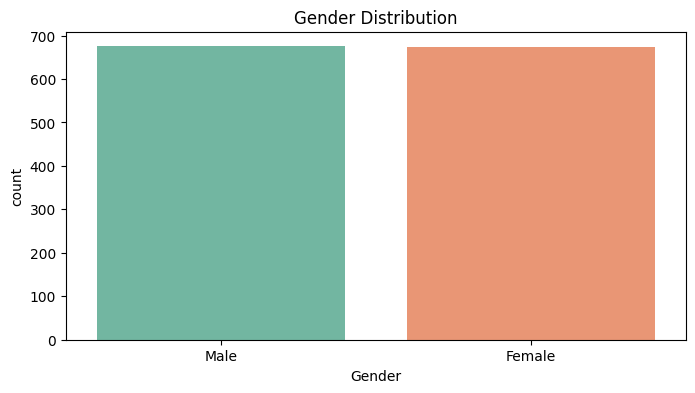

In [8]:
plt.figure(figsize=(8,4))

sns.countplot(data=data, x="Gender", palette="Set2")

plt.title("Gender Distribution")

plt.xticks([0,1],['Male','Female'])

plt.show()

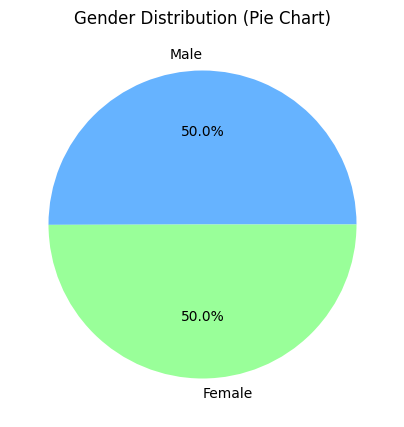

In [9]:
data["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(5,5),
    colors=["#66b3ff","#99ff99"]
)

plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

['HYPERTENSION (Stage-1)' 'HYPERTENSION (Stage-2)' 'HYPERTENSIVE CRISIS'
 'NORMAL']


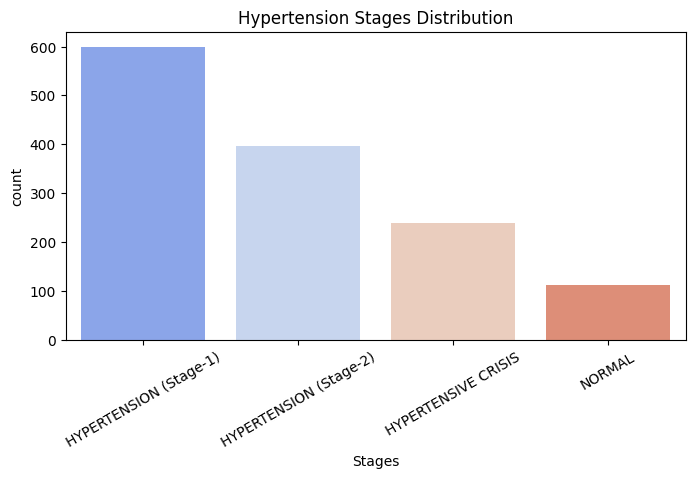

In [10]:
data["Stages"] = data["Stages"].str.strip()

data["Stages"] = data["Stages"].replace({
    "HYPERTENSION (Stage-2).": "HYPERTENSION (Stage-2)",
    "HYPERTENSIVE CRISI": "HYPERTENSIVE CRISIS"
})
print(data["Stages"].unique())

plt.figure(figsize=(8,4))

sns.countplot(data=data, x="Stages", hue="Stages", palette="coolwarm", legend=False)

plt.title("Hypertension Stages Distribution")

plt.xticks(rotation=30)

plt.show()

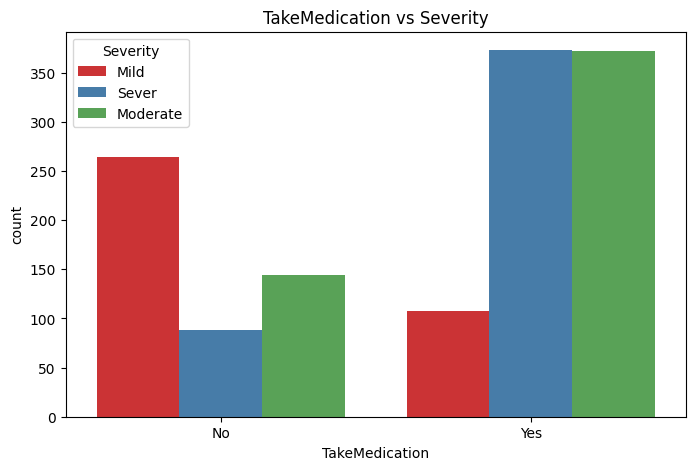

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="TakeMedication", hue="Severity", palette="Set1")

plt.title("TakeMedication vs Severity")

plt.show()

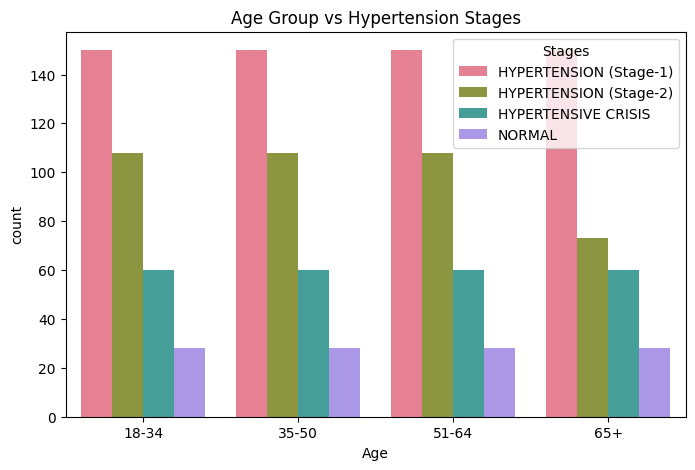

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="Age", hue="Stages", palette="husl")

plt.title("Age Group vs Hypertension Stages")

plt.show()

In [13]:
def range_to_midpoint(val):

    if '-' in str(val):
        start,end = val.split('-')
        return (int(start.strip()) + int(end.strip()))/2

    elif '+' in str(val):
        return int(val.replace('+',''))

    else:
        return np.nan

In [14]:
data['Systolic_num'] = data['Systolic'].apply(range_to_midpoint)

data['Diastolic_num'] = data['Diastolic'].apply(range_to_midpoint)

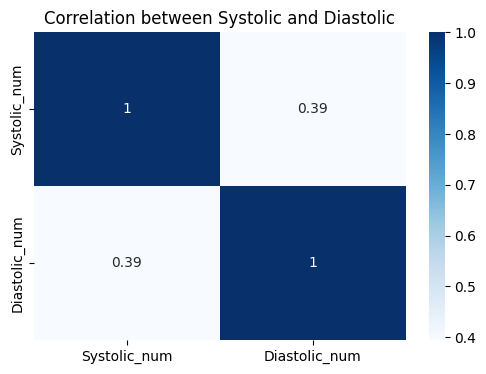

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(data[['Systolic_num','Diastolic_num']].corr(), annot=True, cmap="Blues")

plt.title("Correlation between Systolic and Diastolic")

plt.show()

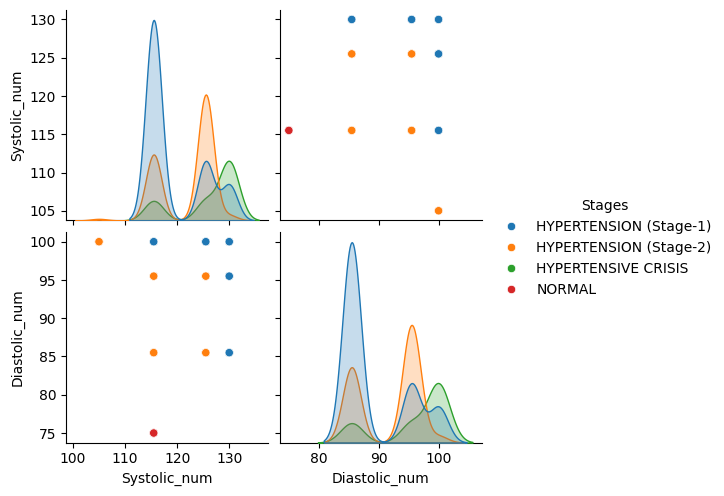

In [16]:
sns.pairplot(data[['Systolic_num','Diastolic_num','Stages']], hue="Stages")

plt.show()

In [17]:
nominal_features=['Gender','History','Patient','TakeMedication','BreathShortness','VisualChanges','NoseBleeding','ControlledDiet']

In [18]:
for col in nominal_features:

    if col == 'Gender':
        data[col] = data[col].map({'Male':0,'Female':1})

    else:
        data[col] = data[col].map({'No':0,'Yes':1})

In [19]:
data['Age'] = data['Age'].map({'18-34':1,'35-50':2,'51-64':3,'65+':4})

data['Severity'] = data['Severity'].map({'Mild':0,'Moderate':1,'Sever':2})

data['Whendiagnoused'] = data['Whendiagnoused'].map({'<1 Year':1,'1-5 Years':2,'>5 Years':3})

data['Systolic'] = data['Systolic'].map({'100 - 110':0,'111 - 120':1,'121 - 130':2,'130+':3})

data['Diastolic'] = data['Diastolic'].map({'70 - 80':0,'81 - 90':1,'91 - 100':2,'100+':3})

data['Stages'] = data['Stages'].map({'NORMAL':0,'HYPERTENSION (Stage-1)':1,'HYPERTENSION (Stage-2)':2,'HYPERTENSIVE CRISIS':3})

In [20]:
data = data.fillna(0)

In [43]:
X = data.drop("Stages", axis=1)
y = data["Stages"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
logreg = LogisticRegression(max_iter=2000)

logreg.fit(X_train,y_train)

y_pred = logreg.predict(X_test)

print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test,y_pred))

print("Classification Report:\n",classification_report(y_test,y_pred))

print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

accuracy['Logistic Regression'] = accuracy_score(y_test,y_pred)

Logistic Regression
Accuracy: 0.9851851851851852
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       109
           2       1.00      0.95      0.98        84
           3       0.93      1.00      0.96        54

    accuracy                           0.99       270
   macro avg       0.98      0.99      0.98       270
weighted avg       0.99      0.99      0.99       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0   0  80   4]
 [  0   0   0  54]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
import joblib

# save model
joblib.dump(logreg, "model.pkl")

# save feature order
joblib.dump(list(X.columns), "columns.pkl")

['columns.pkl']

In [22]:
accuracy={}

In [23]:
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train,y_train)

y_pred = logreg.predict(X_test)

print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test,y_pred))

print("Classification Report:\n",classification_report(y_test,y_pred))

print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

accuracy['Logistic Regression'] = accuracy_score(y_test,y_pred)

Logistic Regression
Accuracy: 0.9814814814814815
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       109
           2       1.00      0.94      0.97        84
           3       0.92      1.00      0.96        54

    accuracy                           0.98       270
   macro avg       0.98      0.99      0.98       270
weighted avg       0.98      0.98      0.98       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0   0  79   5]
 [  0   0   0  54]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
decisionTree = DecisionTreeClassifier()
decisionTree.fit(X_train, y_train)

y_pred = decisionTree.predict(X_test)

print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Decision Tree'] = accuracy_score(y_test, y_pred)

Decision Tree:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       109
           2       1.00      1.00      1.00        84
           3       1.00      1.00      1.00        54

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0   0  84   0]
 [  0   0   0  54]]


In [25]:
randomforest = RandomForestClassifier()
randomforest.fit(X_train, y_train)

y_pred = randomforest.predict(X_test)

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Random Forest'] = accuracy_score(y_test, y_pred)

Random Forest:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       109
           2       1.00      1.00      1.00        84
           3       1.00      1.00      1.00        54

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0   0  84   0]
 [  0   0   0  54]]


In [26]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['SVM'] = accuracy_score(y_test, y_pred)

SVM:
Accuracy: 0.4888888888888889
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.44      1.00      0.61       109
           2       0.00      0.00      0.00        84
           3       0.00      0.00      0.00        54

    accuracy                           0.49       270
   macro avg       0.36      0.50      0.40       270
weighted avg       0.26      0.49      0.33       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0  84   0   0]
 [  0  54   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("KNN:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['KNN'] = accuracy_score(y_test, y_pred)

KNN:
Accuracy: 0.9851851851851852
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       109
           2       1.00      0.95      0.98        84
           3       0.93      1.00      0.96        54

    accuracy                           0.99       270
   macro avg       0.98      0.99      0.98       270
weighted avg       0.99      0.99      0.99       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0   0  80   4]
 [  0   0   0  54]]


In [28]:
RC = RidgeClassifier()
RC.fit(X_train, y_train)

y_pred = RC.predict(X_test)

print("RidgeClassifier:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['RidgeClassifier'] = accuracy_score(y_test, y_pred)

RidgeClassifier:
Accuracy: 0.9481481481481482
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.61      0.76        23
           1       0.92      1.00      0.96       109
           2       1.00      0.94      0.97        84
           3       0.92      1.00      0.96        54

    accuracy                           0.95       270
   macro avg       0.96      0.89      0.91       270
weighted avg       0.95      0.95      0.94       270

Confusion Matrix:
 [[ 14   9   0   0]
 [  0 109   0   0]
 [  0   0  79   5]
 [  0   0   0  54]]


In [29]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)

y_pred = naive_bayes.predict(X_test)

print("Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Naive Bayes'] = accuracy_score(y_test, y_pred)

Naive Bayes:
Accuracy: 0.8444444444444444
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       109
           2       1.00      0.50      0.67        84
           3       0.56      1.00      0.72        54

    accuracy                           0.84       270
   macro avg       0.89      0.88      0.85       270
weighted avg       0.91      0.84      0.84       270

Confusion Matrix:
 [[ 23   0   0   0]
 [  0 109   0   0]
 [  0   0  42  42]
 [  0   0   0  54]]


In [30]:
accuracy_df = pd.DataFrame(accuracy.items(), columns=['Model','Accuracy'])

accuracy_df.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
4,KNN,0.985185
0,Logistic Regression,0.981481
5,RidgeClassifier,0.948148
6,Naive Bayes,0.844444
3,SVM,0.488889


In [31]:
import joblib

joblib.dump(logreg, "logreg_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
def predict_hypertension(features):
    prediction = logreg.predict([features])

    stages = {
        0:"NORMAL",
        1:"HYPERTENSION (Stage-1)",
        2:"HYPERTENSION (Stage-2)",
        3:"HYPERTENSIVE CRISIS"
    }

    return stages[prediction[0]]

In [34]:
sample = [0,1,1,0,0,0,0,0,0,1,1,1,0,110,80]

predict_hypertension(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'HYPERTENSION (Stage-1)'

In [39]:
print(logreg.predict(X_test[:10]))
print(y_test[:10].values)

[3 1 3 2 1 1 2 1 3 1]
[3 1 3 2 1 1 2 1 3 1]


In [40]:
print(data["Stages"].unique())

[1 2 3 0]


In [41]:
print(X.columns)

Index(['Gender', 'Age', 'History', 'Patient', 'TakeMedication', 'Severity',
       'BreathShortness', 'VisualChanges', 'NoseBleeding', 'Whendiagnoused',
       'Systolic', 'Diastolic', 'ControlledDiet', 'Systolic_num',
       'Diastolic_num'],
      dtype='object')


In [42]:
import joblib
joblib.dump(logreg, "logreg_model.pkl")

['logreg_model.pkl']